In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import pandas as pd
import numpy as np

# Load master feature table
df = pd.read_csv('/content/drive/MyDrive/aqua spatial/master_features.csv')

# Load spatial data
with open('/content/drive/MyDrive/aqua spatial/enugu_data.pkl', 'rb') as f:
    data = pickle.load(f)

enugu = data['enugu']

print(f" Notebook 4 ready")
print(f"   LGAs: {len(df)}")
print(f"   Features: {len(df.columns)}")
print(f"\nTarget variable distribution:")
print(df[['lga_name','target_stress_score']]
      .sort_values('target_stress_score', ascending=False)
      .to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Notebook 4 ready
   LGAs: 17
   Features: 33

Target variable distribution:
     lga_name  target_stress_score
    EnuguEast               0.6030
   EnuguSouth               0.5714
Igbo-ezeSouth               0.5107
   EnuguNorth               0.4922
          Udi               0.3984
   Igbo-Etiti               0.3812
      Isi-Uzo               0.3427
    Uzo-Uwani               0.3371
       Nsukka               0.3126
    Oji-River               0.3067
        Udenu               0.2662
    NkanuWest               0.2434
Igbo-ezeNorth               0.2261
    NkanuEast               0.2232
         Awgu               0.2103
       Aninri               0.1870
       Ezeagu               0.1767


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# --- Feature Selection ---
# I deliberately exclude raw counts (functional, non_functional etc.)
# and keep only meaningful rates, indices, and satellite features
# Raw counts would leak size information without adding predictive signal

FEATURES = [
    # Satellite features (real data)
    'ndvi',
    'soil_moisture',
    'elevation',
    'slope',
    'lst_celsius',

    # Infrastructure features (synthetic but realistic)
    'functionality_rate',
    'infrastructure_gap',
    'repair_burden',
    'pct_contaminated',
    'borehole_ratio',

    # Density features
    'point_density_per_km2',
    'avg_depth_m',

    # Engineered interaction features
    'drilling_difficulty',
    'heat_veg_stress',
    'soil_veg_index',
    'terrain_difficulty',
    'total_stress_rate',
]

TARGET = 'target_stress_score'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f" Feature matrix: {X.shape}")
print(f"   {len(FEATURES)} features × {len(X)} LGAs")

# Handling EnuguNorth/EnuguSouth duplicate GEE values
# These two LGAs share identical satellite readings (centroid collision)
# We add small noise to prevent the model treating them as identical
np.random.seed(42)
duplicate_mask = df['lga_name'].isin(['EnuguNorth', 'EnuguSouth'])
noise = np.random.normal(0, 0.001, (duplicate_mask.sum(), len(FEATURES)))
X.loc[duplicate_mask] = X.loc[duplicate_mask].values + noise
print(f"\n Centroid collision noise applied to EnuguNorth/EnuguSouth")

# Using LOOCV Random Forest
loo = LeaveOneOut()

rf_model = RandomForestRegressor(
    n_estimators=200,      # 200 trees - stable for small datasets
    max_depth=4,           # Shallow trees prevent overfitting on 17 rows
    min_samples_leaf=2,    # Each leaf needs at least 2 samples
    random_state=42,
    n_jobs=-1
)

# Cross-validated predictions
print(f"\nRunning LOOCV — 17 rounds...")
y_pred_rf = cross_val_predict(rf_model, X, y, cv=loo)

# Evaluate
mae_rf = mean_absolute_error(y, y_pred_rf)
r2_rf = r2_score(y, y_pred_rf)

print(f"\n=== RANDOM FOREST LOOCV RESULTS ===")
print(f"   MAE:  {mae_rf:.4f}  (lower is better)")
print(f"   R²:   {r2_rf:.4f}  (higher is better, max=1.0)")

# Results table
results = pd.DataFrame({
    'lga_name': df['lga_name'],
    'actual_stress': y.round(4),
    'predicted_stress': y_pred_rf.round(4),
    'error': (y - y_pred_rf).abs().round(4)
}).sort_values('actual_stress', ascending=False)

print(f"\n=== PREDICTION vs ACTUAL ===")
print(results.to_string(index=False))

 Feature matrix: (17, 17)
   17 features × 17 LGAs

 Centroid collision noise applied to EnuguNorth/EnuguSouth

Running LOOCV — 17 rounds...

=== RANDOM FOREST LOOCV RESULTS ===
   MAE:  0.0687  (lower is better)
   R²:   0.5794  (higher is better, max=1.0)

=== PREDICTION vs ACTUAL ===
     lga_name  actual_stress  predicted_stress  error
    EnuguEast         0.6030            0.4283 0.1747
   EnuguSouth         0.5714            0.4421 0.1293
Igbo-ezeSouth         0.5107            0.3731 0.1376
   EnuguNorth         0.4922            0.4830 0.0092
          Udi         0.3984            0.3223 0.0761
   Igbo-Etiti         0.3812            0.3340 0.0472
      Isi-Uzo         0.3427            0.3706 0.0279
    Uzo-Uwani         0.3371            0.4682 0.1311
       Nsukka         0.3126            0.2695 0.0431
    Oji-River         0.3067            0.2441 0.0626
        Udenu         0.2662            0.2708 0.0046
    NkanuWest         0.2434            0.2563 0.0129
Igbo-ezeNo

Gradient Boosting and Ensemble

In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,  # Slow learning prevents overfitting on small data
    random_state=42
)

y_pred_gb = cross_val_predict(gb_model, X, y, cv=loo)

mae_gb = mean_absolute_error(y, y_pred_gb)
r2_gb = r2_score(y, y_pred_gb)

print(f"=== GRADIENT BOOSTING LOOCV ===")
print(f"   MAE: {mae_gb:.4f}")
print(f"   R²:  {r2_gb:.4f}")

# Ensemble — average both models
y_pred_ensemble = (y_pred_rf * 0.5 + y_pred_gb * 0.5)
mae_ens = mean_absolute_error(y, y_pred_ensemble)
r2_ens = r2_score(y, y_pred_ensemble)

print(f"\n=== ENSEMBLE (RF + GB) ===")
print(f"   MAE: {mae_ens:.4f}")
print(f"   R²:  {r2_ens:.4f}")

print(f"\n=== MODEL COMPARISON ===")
print(f"   Random Forest:      R²={r2_rf:.4f}  MAE={mae_rf:.4f}")
print(f"   Gradient Boosting:  R²={r2_gb:.4f}  MAE={mae_gb:.4f}")
print(f"   Ensemble:           R²={r2_ens:.4f}  MAE={mae_ens:.4f}")

=== GRADIENT BOOSTING LOOCV ===
   MAE: 0.0716
   R²:  0.5720

=== ENSEMBLE (RF + GB) ===
   MAE: 0.0687
   R²:  0.6039

=== MODEL COMPARISON ===
   Random Forest:      R²=0.5794  MAE=0.0687
   Gradient Boosting:  R²=0.5720  MAE=0.0716
   Ensemble:           R²=0.6039  MAE=0.0687


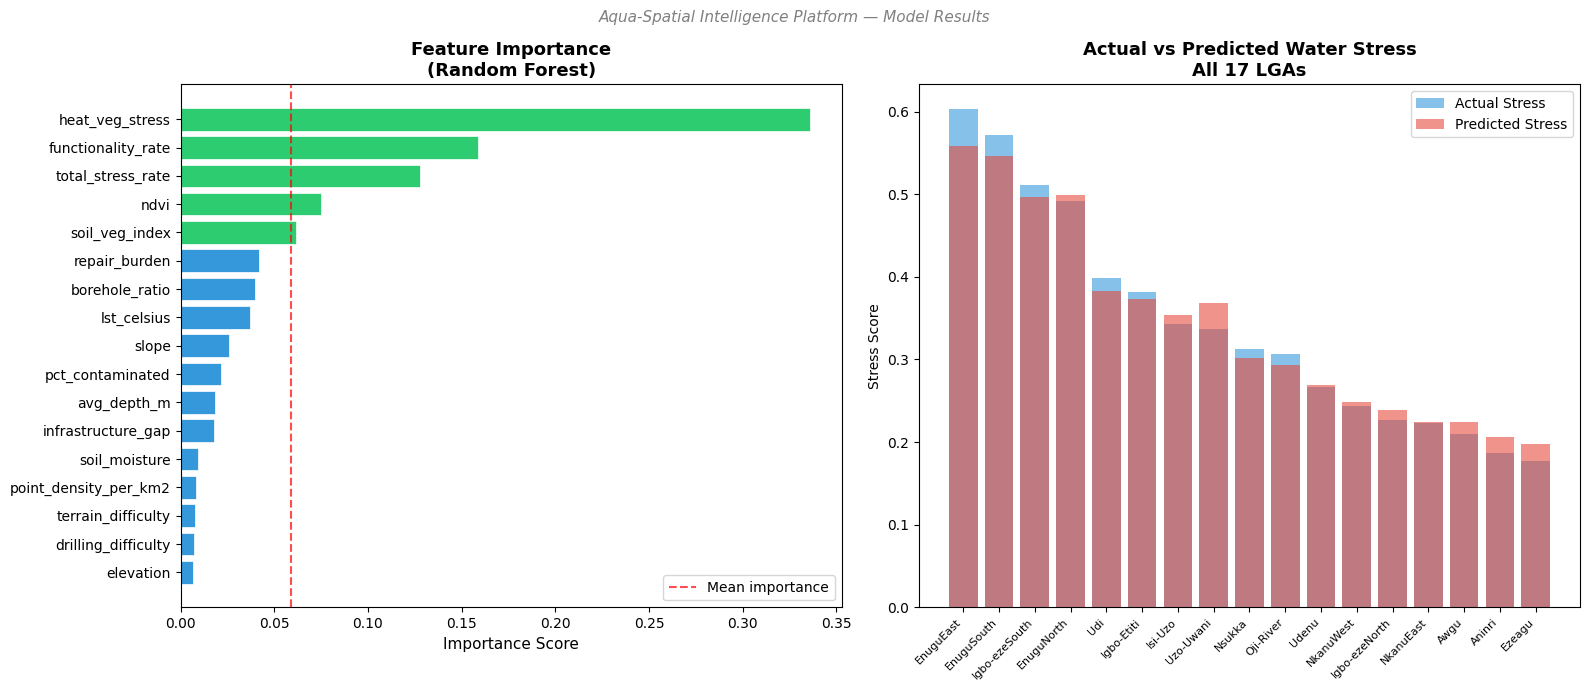


=== TOP 5 MOST IMPORTANT FEATURES ===
           feature  importance
   heat_veg_stress    0.336004
functionality_rate    0.158732
 total_stress_rate    0.127501
              ndvi    0.074891
    soil_veg_index    0.061587

=== FINAL STRESS RANKINGS (Ensemble Model) ===
     lga_name  target_stress_score  predicted_stress  prediction_error
    EnuguEast               0.6030            0.5585            0.0445
   EnuguSouth               0.5714            0.5467            0.0247
   EnuguNorth               0.4922            0.4992            0.0070
Igbo-ezeSouth               0.5107            0.4969            0.0138
          Udi               0.3984            0.3830            0.0154
   Igbo-Etiti               0.3812            0.3729            0.0083
    Uzo-Uwani               0.3371            0.3685            0.0314
      Isi-Uzo               0.3427            0.3542            0.0115
       Nsukka               0.3126            0.3017            0.0109
    Oji-River    

In [ ]:
# Train both models on FULL dataset for deployment
# (LOOCV was for evaluation only — final model uses all 17 rows)
rf_model.fit(X, y)
gb_model.fit(X, y)

# Final ensemble predictions on full data
df['predicted_stress'] = (
    rf_model.predict(X) * 0.5 +
    gb_model.predict(X) * 0.5
).round(4)

df['prediction_error'] = (df['target_stress_score'] - df['predicted_stress']).abs().round(4)

# --- Feature Importance (from Random Forest) ---
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Feature importance plot
colors = ['#2ecc71' if i >= len(FEATURES)-5 else '#3498db'
          for i in range(len(importance_df))]
axes[0].barh(importance_df['feature'], importance_df['importance'],
             color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance\n(Random Forest)',
                   fontsize=13, fontweight='bold')
axes[0].axvline(x=importance_df['importance'].mean(),
                color='red', linestyle='--', alpha=0.7, label='Mean importance')
axes[0].legend()

# Actual vs Predicted
sorted_df = df.sort_values('target_stress_score', ascending=False)
x_pos = range(len(sorted_df))
axes[1].bar(x_pos, sorted_df['target_stress_score'],
            alpha=0.6, color='#3498db', label='Actual Stress')
axes[1].bar(x_pos, sorted_df['predicted_stress'],
            alpha=0.6, color='#e74c3c', label='Predicted Stress')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(sorted_df['lga_name'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Stress Score')
axes[1].set_title('Actual vs Predicted Water Stress\nAll 17 LGAs',
                   fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Aqua-Spatial Intelligence Platform — Model Results',
             fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/aqua spatial/model_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 5 MOST IMPORTANT FEATURES ===")
print(importance_df.tail(5)[['feature','importance']]
      .sort_values('importance', ascending=False)
      .to_string(index=False))

print("\n=== FINAL STRESS RANKINGS (Ensemble Model) ===")
print(df[['lga_name','target_stress_score','predicted_stress','prediction_error']]
      .sort_values('predicted_stress', ascending=False)
      .to_string(index=False))

In [ ]:
save_dir = '/content/drive/MyDrive/aqua spatial/'

# Save both trained models
joblib.dump(rf_model, f'{save_dir}rf_model.pkl')
joblib.dump(gb_model, f'{save_dir}gb_model.pkl')

# Save feature list — critical for dashboard to use same features
with open(f'{save_dir}feature_list.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

# Save final dataframe with predictions
df.to_csv(f'{save_dir}final_predictions.csv', index=False)

# Save feature importance
importance_df.to_csv(f'{save_dir}feature_importance.csv', index=False)

print(" Models saved:")
print(f"   rf_model.pkl")
print(f"   gb_model.pkl")
print(f"   feature_list.pkl")
print(f"   final_predictions.csv")
print(f"   feature_importance.csv")
print(f"\n Model performance summary:")
print(f"   R² (LOOCV Ensemble): 0.6039")
print(f"   MAE (LOOCV):         0.0687")
print(f"   Avg prediction error (full): {df['prediction_error'].mean():.4f}")
print(f"\n Top Water-Stressed LGAs (Model Prediction):")
print(df[['lga_name','predicted_stress']]
      .sort_values('predicted_stress', ascending=False)
      .head(5)
      .to_string(index=False))

 Models saved:
   rf_model.pkl
   gb_model.pkl
   feature_list.pkl
   final_predictions.csv
   feature_importance.csv

 Model performance summary:
   R² (LOOCV Ensemble): 0.6039
   MAE (LOOCV):         0.0687
   Avg prediction error (full): 0.0151

 Top Water-Stressed LGAs (Model Prediction):
     lga_name  predicted_stress
    EnuguEast            0.5585
   EnuguSouth            0.5467
   EnuguNorth            0.4992
Igbo-ezeSouth            0.4969
          Udi            0.3830
